In [18]:
#### Dependencies ####
import json
import numpy as np
import logging
import sys
import time
import joblib
import matplotlib.pyplot as plt
import torch
import cortex # This dependency is pycortex, which enables the plotting of flatmaps. It can be disabled.
from cvxopt import matrix, solvers # Only necessary for the stacked model.
from transformers import AutoTokenizer, AutoModelForCausalLM # Only necessary for feature extraction.

# Repository imports
from ridge_utils.ridge import bootstrap_ridge
import ridge_utils.npp
from ridge_utils.util import make_delayed
from ridge_utils.dsutils import make_word_ds
from ridge_utils.DataSequence import DataSequence
from ridge_utils.tokenization_helpers import generate_efficient_feat_dicts_opt
from ridge_utils.tokenization_helpers import convert_to_feature_mats_opt

### Some extra helper functions

zscore = lambda v: (v - v.mean(0)) / v.std(0)
zscore.__doc__ = """Z-scores (standardizes) each column of [v]."""
zs = zscore

## Matrix corr -- find correlation between each column of c1 and the corresponding column of c2
mcorr = lambda c1, c2: (zs(c1) * zs(c2)).mean(0)
mcorr.__doc__ = """Matrix correlation. Find the correlation between each column of [c1] and the corresponding column of [c2]."""

### Ignore irrelevant warnings that muck up the notebook
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Some parameters
NUM_VOX = 95556 # Number of voxels in the subject we plan to use
NUM_TRS = 790 # Number of TRs across 3 test stories
trim_start = 50 # Trim 50 TRs off the start of the story
trim_end = 5 # Trim 5 off the back
ndelays = 4 # We use 4 FIR delays (2 seconds, 4 seconds, 6 seconds, 8 seconds)
delays = range(1, ndelays + 1)

In [19]:
WHICH_LAYERS = 'all' # single, all

fpath = '/home/echeng/encoding-models/results/{}/results_{}_n_layers_0_seed_layer_{}_y_rank_{}_{}_ridge_{}.json' # model(no company), layer, rank (int), method, alpha
MODEL = 'opt-125m'
LAYER = 9
METHODS = ['I']
RANKS = [1000]
ALPHA = 0.05


In [20]:
results = []
for i, METHOD in enumerate(METHODS):
    RANK = RANKS[i]
    file = fpath.format(MODEL, WHICH_LAYERS, LAYER, RANK, METHOD, ALPHA)
    print(file)
    with open(file, 'r') as f:
        result = json.load(f)
    results.append(result)

/home/echeng/encoding-models/results/opt-125m/results_all_n_layers_0_seed_layer_9_y_rank_1000_I_ridge_0.05.json


In [99]:
# Plot diff

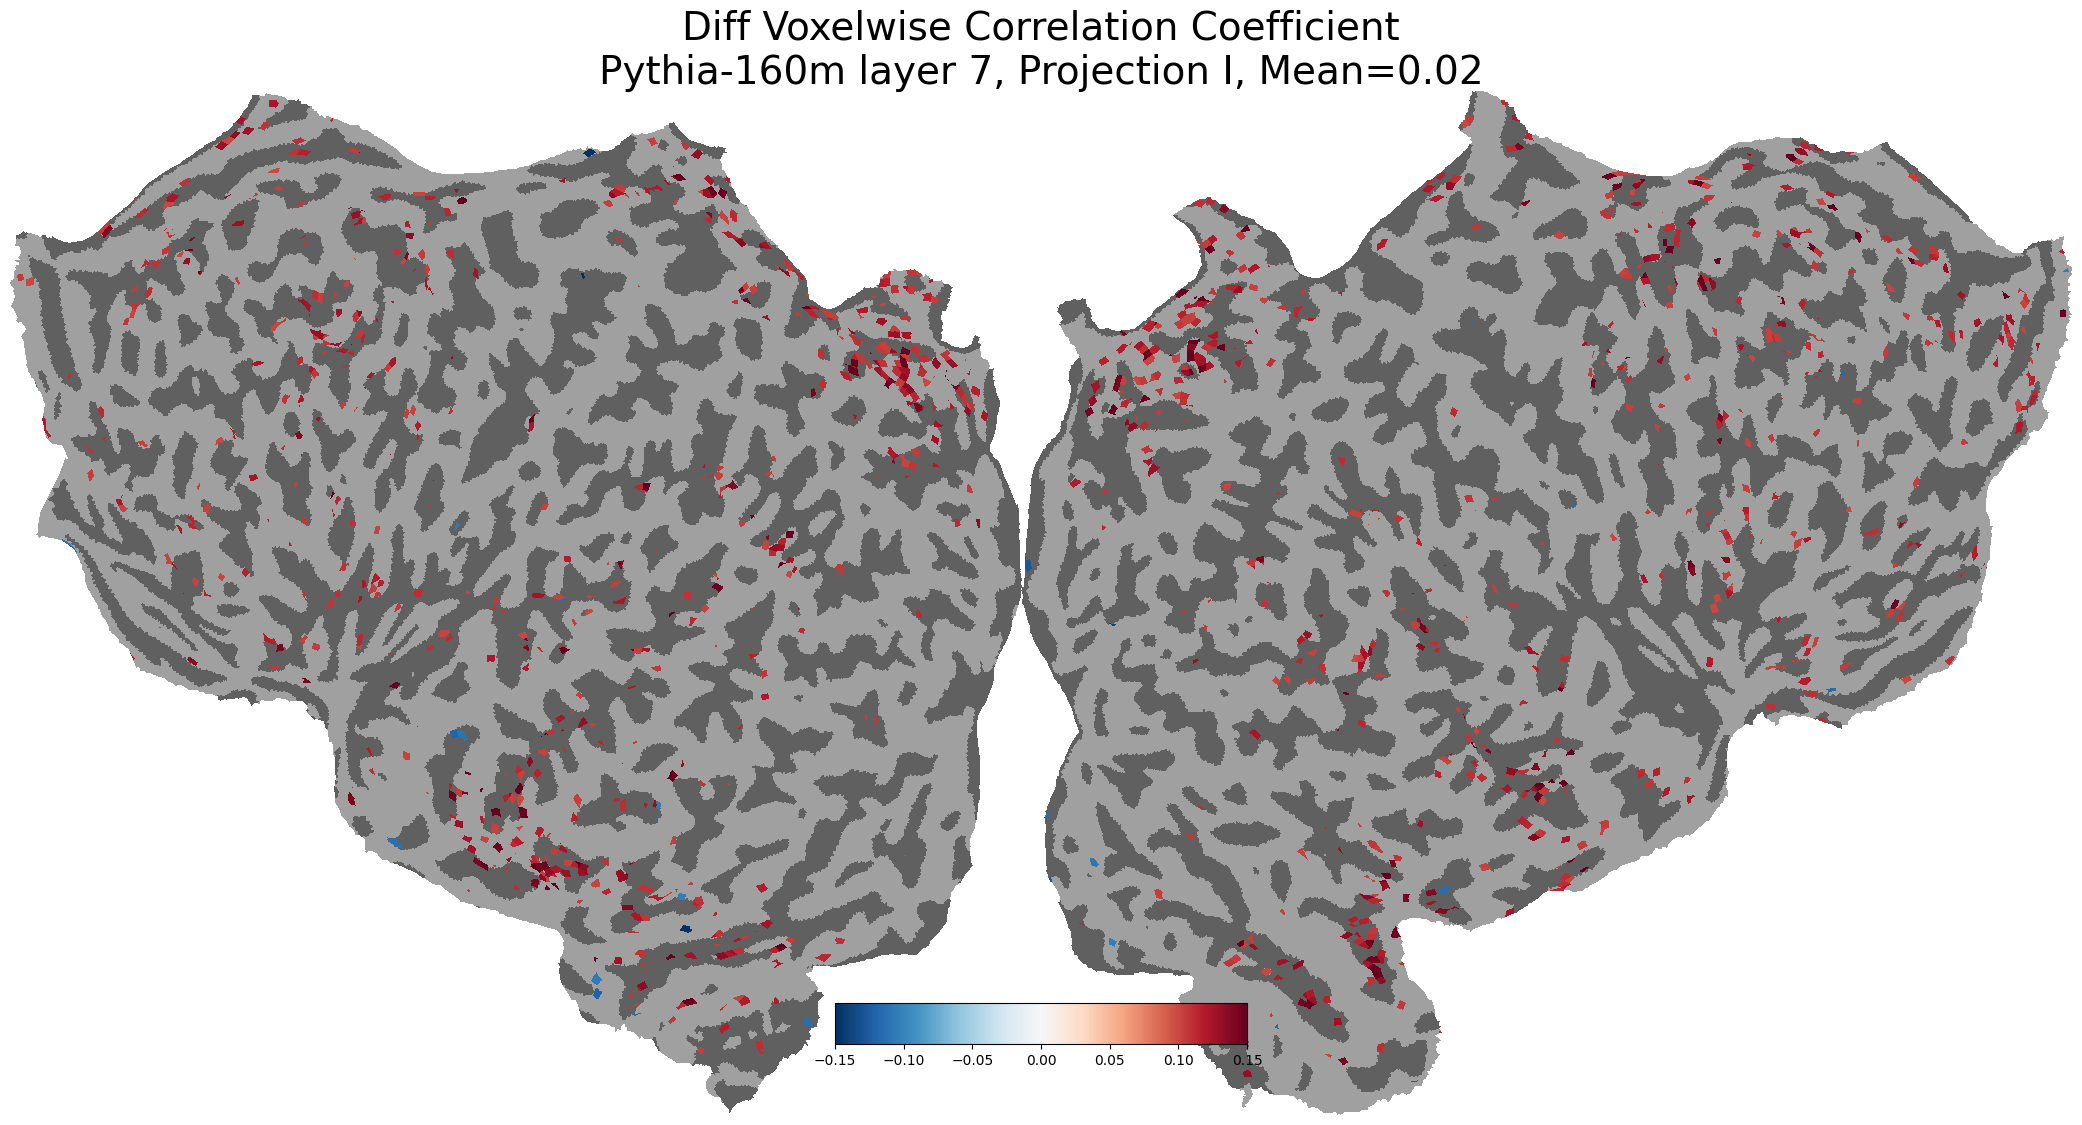

In [100]:
diff_corrs = np.array(results[0]['correlations_response_test']) - np.array(results[1]['correlations_response_test'])
acc = []
for ei, i in enumerate(diff_corrs):
    if np.abs(i) <= 0.1:
        acc.append(np.nan)
    else:
        acc.append(i)
acc = np.array(acc)
vol = cortex.Volume(acc, 'AA', '20180905AA-sg-auto', vmin=-0.15, vmax=0.15)
cortex.quickshow(vol, with_colorbar=True, linewidth=4, thick=1, with_curvature=True, with_rois=False)
plt.title(f"Diff Voxelwise Correlation Coefficient\n{MODEL.capitalize()} layer {LAYER}, Projection {METHOD}, Mean={np.mean(diff_corrs):.2f}", size=28);

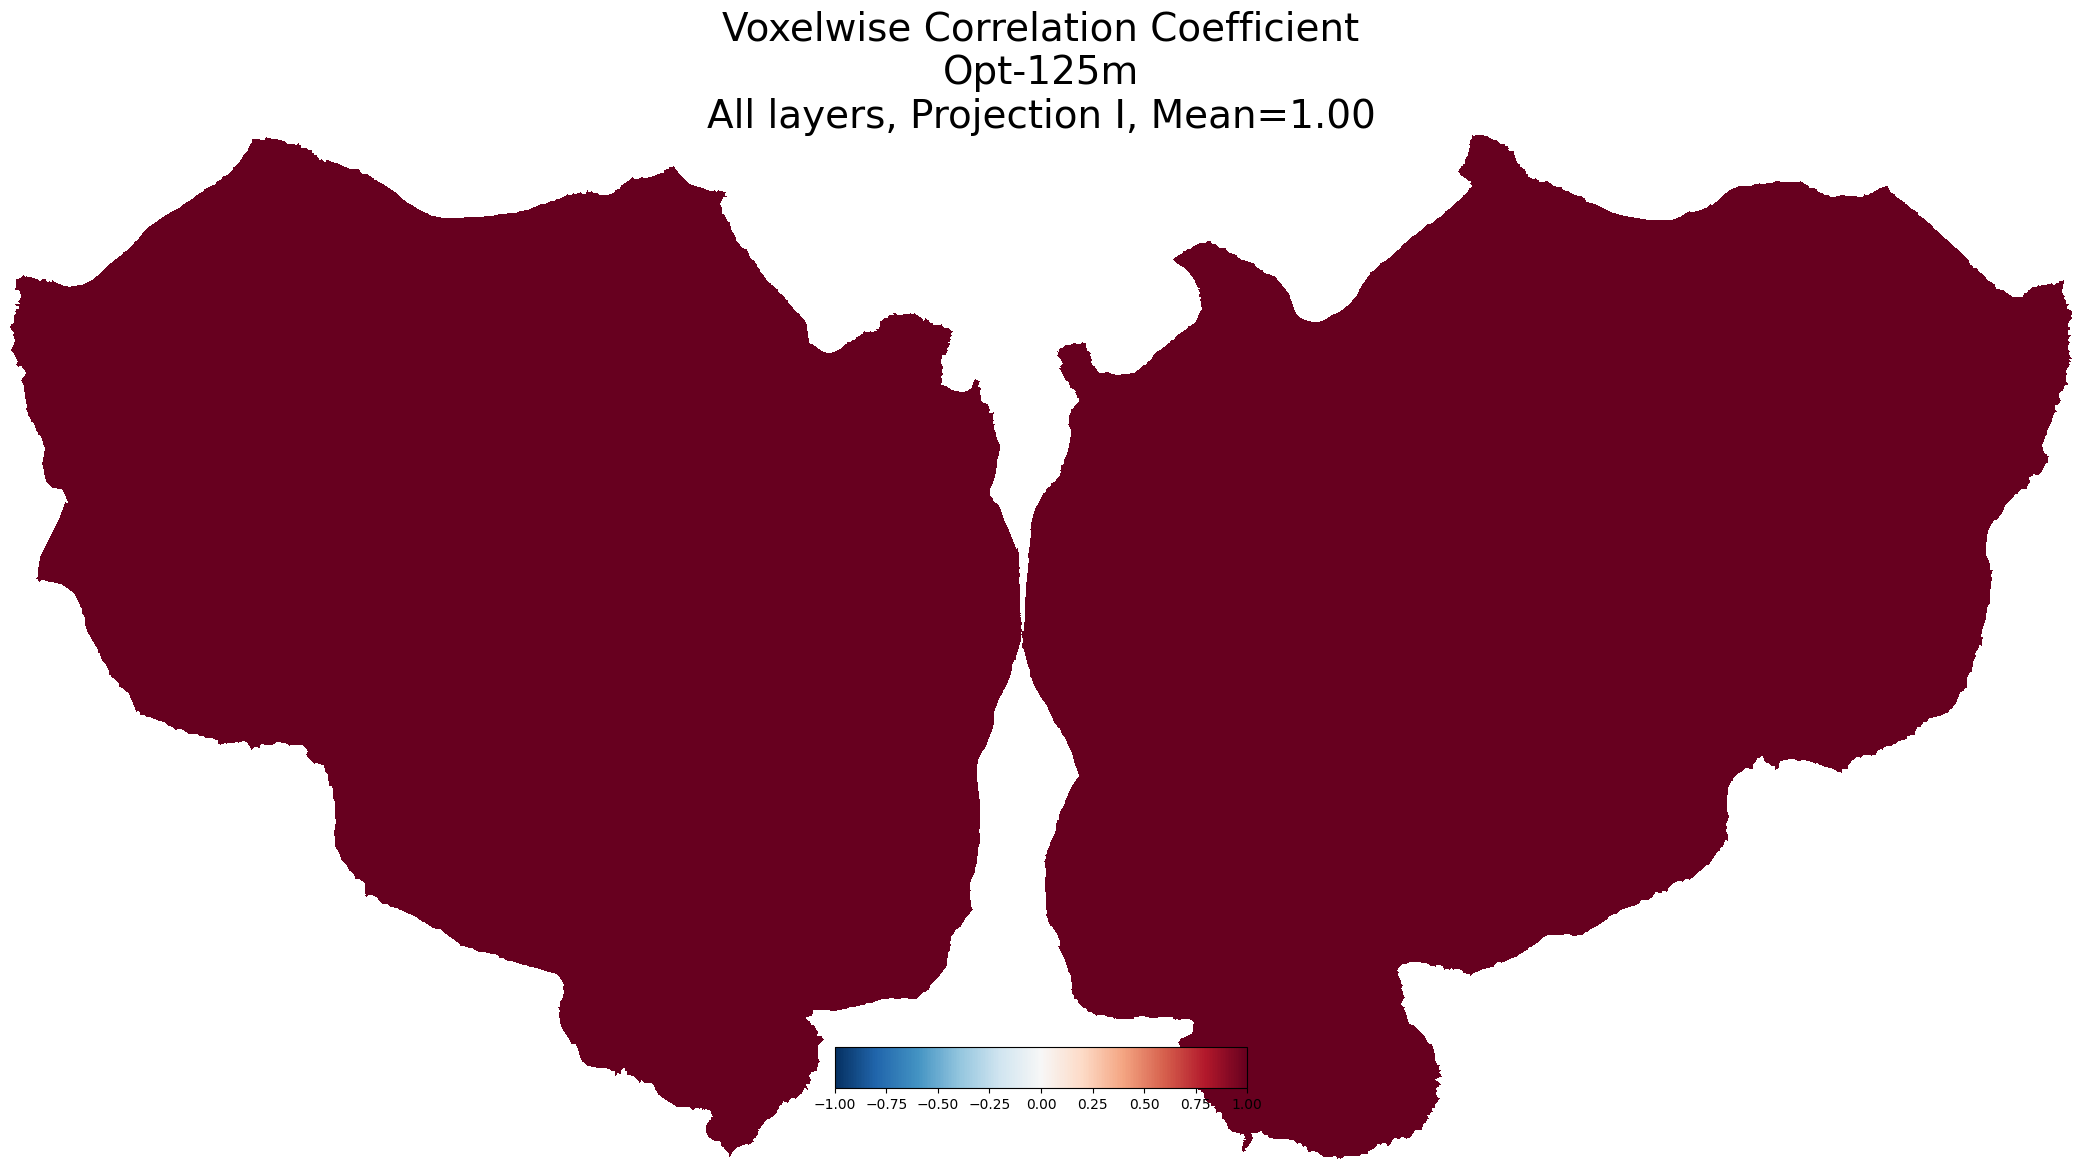

In [23]:
for i, METHOD in enumerate(METHODS):
    corrs = results[i]['correlations_response']
    acc = []
    for ei, i in enumerate(corrs):
        if np.abs(i) <= 0.1:
            acc.append(np.nan)
        else:
            acc.append(i)
    acc = np.array(acc)
    vol = cortex.Volume(acc, 'AA', '20180905AA-sg-auto', vmin=-1, vmax=1)
    cortex.quickshow(vol, with_colorbar=True, linewidth=4, thick=1, with_curvature=True, with_rois=False)

    if WHICH_LAYERS == 'single':
        layer_str = f"layer {LAYER}"
    elif WHICH_LAYERS == 'every_other':
        layer_str = f'every third layer'
    else:
        layer_str = 'all layers'
    
    plt.title(f"Voxelwise Correlation Coefficient\n{MODEL.capitalize()}\n{layer_str.capitalize()}, Projection {METHOD}, Mean={np.mean(corrs):.2f}", size=28);